600345 ไทโย


[Web สรุปข้อมูลจาก colab](https://income-visualize66.vercel.app/) โดยนำผลลัพธ์มา visualize บนเว็บเพื่อตวามสะดวก

**Import lib ต่างๆ + setup font สำหรับ graph**
ในการรัน colab นี้ต้องมี dataset ข้อมูลชื่อ avg_income.csv อยู่ใน root directory ของ colab [Dataset Source](https://www.thackle.or.th/en/dataset/92)

In [3]:
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

plt.rcParams["font.family"] = "Tahoma"
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New', size=16)
sns.set_theme(style="whitegrid", font="TH Sarabun New")
plt.rcParams['figure.dpi'] = 120

# Init

**สำรวจข้อมูลคร่าวๆ**

In [4]:
# ดูข้อมูลคร่าวๆ
df_raw = pd.read_csv("avg_income.csv")

print("shape:", df_raw.shape)
display(df_raw.head())
display(df_raw.info())
display(df_raw.describe(include="all"))

shape: (7700, 11)


,year,province,source_income1,source_income2,source_income3,soc_eco_class1,soc_eco_class2,value,unit,attribute,source
0,2566,กรุงเทพมหานคร,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,29549.0,บาท,NaN,สำนักงานสถิติแห่งชาติ
1,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ประจำ,รายได้ประจำ,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,29549.0,บาท,NaN,สำนักงานสถิติแห่งชาติ
2,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,รายได้ที่เป็นตัวเงิน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,23925.0,บาท,NaN,สำนักงานสถิติแห่งชาติ
3,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,ค่าจ้างและเงินเดือน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,0.0,บาท,ศูนย์ยกกำลังดับเบิลยู หมายถึง ข้อมูลจากการสำรว...,สำนักงานสถิติแห่งชาติ
4,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,กำไรสุทธิจากการทำธุรกิจ,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,0.0,บาท,ศูนย์ยกกำลังดับเบิลยู หมายถึง ข้อมูลจากการสำรว...,สำนักงานสถิติแห่งชาติ


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7700 entries, 0 to 7699
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            7700 non-null   int64  
 1   province        7700 non-null   object 
 2   source_income1  7700 non-null   object 
 3   source_income2  7700 non-null   object 
 4   source_income3  7700 non-null   object 
 5   soc_eco_class1  7700 non-null   object 
 6   soc_eco_class2  7700 non-null   object 
 7   value           7700 non-null   float64
 8   unit            7700 non-null   object 
 9   attribute       835 non-null    object 
 10  source          7700 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 661.8+ KB


None

,year,province,source_income1,source_income2,source_income3,soc_eco_class1,soc_eco_class2,value,unit,attribute,source
count,7700.0,7700,7700,7700,7700,7700,7700,7700.000000,7700,835,7700
unique,NaN,77,3,5,10,4,10,NaN,1,3,1
top,NaN,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,รายได้ทั้งสิ้นต่อเดือน,ลูกจ้าง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,NaN,บาท,ศูนย์ยกกำลังดับเบิลยู หมายถึง ข้อมูลจากการสำรว...,สำนักงานสถิติแห่งชาติ
freq,NaN,100,6160,4620,770,3850,770,NaN,7700,812,7700
mean,2566.0,NaN,NaN,NaN,NaN,NaN,NaN,9697.004805,NaN,NaN,NaN
std,0.0,NaN,NaN,NaN,NaN,NaN,NaN,13793.777270,NaN,NaN,NaN
min,2566.0,NaN,NaN,NaN,NaN,NaN,NaN,-2250.000000,NaN,NaN,NaN
25%,2566.0,NaN,NaN,NaN,NaN,NaN,NaN,256.000000,NaN,NaN,NaN
50%,2566.0,NaN,NaN,NaN,NaN,NaN,NaN,2588.500000,NaN,NaN,NaN
75%,2566.0,NaN,NaN,NaN,NaN,NaN,NaN,16577.750000,NaN,NaN,NaN


# Data cleaning

**Clean ข้อมูล**

In [5]:
# ตรวจ missing
missing_summary = df_raw.isna().sum().to_frame("missing_count")
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(df_raw) * 100).round(2)
display(missing_summary)

# ตรวจ duplicate
duplicate_count = df_raw.duplicated().sum()
print("Duplicate rows:", duplicate_count)

# ตรวจ type
print(df_raw.dtypes)

,missing_count,missing_pct
year,0,0.00
province,0,0.00
source_income1,0,0.00
source_income2,0,0.00
source_income3,0,0.00
soc_eco_class1,0,0.00
soc_eco_class2,0,0.00
value,0,0.00
unit,0,0.00
attribute,6865,89.16


Duplicate rows: 0
year                int64
province           object
source_income1     object
source_income2     object
source_income3     object
soc_eco_class1     object
soc_eco_class2     object
value             float64
unit               object
attribute          object
source             object
dtype: object


In [6]:
cleaning_log = []

# copy
df = df_raw.copy()
cleaning_log.append("สร้างสำเนาข้อมูลจาก df_raw -> df")

# strip space ชื่อคอลัมน์
old_cols = df.columns.tolist()
df.columns = df.columns.str.strip()
cleaning_log.append("ลบ space เกินในชื่อคอลัมน์")

# strip space ใน string columns
str_cols = df.select_dtypes(include="object").columns
for col in str_cols:
    df[col] = df[col].astype(str).str.strip()
cleaning_log.append("ลบ space เกินในข้อมูลประเภทข้อความ")

# แก้ค่า 'nan' string ที่เกิดจาก astype(str) กลับเป็น np.nan
for col in str_cols:
    df[col] = df[col].replace("nan", np.nan)
cleaning_log.append("แปลง string 'nan' กลับเป็น missing value")

# แปลง type
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["value"] = pd.to_numeric(df["value"], errors="coerce")
cleaning_log.append("แปลง year เป็น Int64 และ value เป็น numeric")

# ลบ duplicate ถ้ามี
before = len(df)
df = df.drop_duplicates()
after = len(df)
cleaning_log.append(f"ลบข้อมูลซ้ำ: {before - after} แถว")

# สร้าง flag สำหรับ attribute ที่เป็น 0 จากการปัดเศษ/ประมาณค่า
df["zero_flag"] = df["attribute"].fillna("").str.contains("ค่าเป็น 0|ปัดเศษแล้วเป็น 0", regex=True)
cleaning_log.append("สร้าง zero_flag เพื่อระบุค่าที่เป็น 0 จากหมายเหตุ attribute")

# ตรวจค่าหลัก
display(df.head())
print("shape after cleaning:", df.shape)

print("\n=== CLEANING LOG ===")
for i, log in enumerate(cleaning_log, 1):
    print(f"{i}. {log}")

,year,province,source_income1,source_income2,source_income3,soc_eco_class1,soc_eco_class2,value,unit,attribute,source,zero_flag
0,2566,กรุงเทพมหานคร,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,29549.0,บาท,NaN,สำนักงานสถิติแห่งชาติ,False
1,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ประจำ,รายได้ประจำ,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,29549.0,บาท,NaN,สำนักงานสถิติแห่งชาติ,False
2,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,รายได้ที่เป็นตัวเงิน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,23925.0,บาท,NaN,สำนักงานสถิติแห่งชาติ,False
3,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,ค่าจ้างและเงินเดือน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,0.0,บาท,ศูนย์ยกกำลังดับเบิลยู หมายถึง ข้อมูลจากการสำรว...,สำนักงานสถิติแห่งชาติ,True
4,2566,กรุงเทพมหานคร,รายได้ประจำ,รายได้ที่เป็นตัวเงิน,กำไรสุทธิจากการทำธุรกิจ,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,0.0,บาท,ศูนย์ยกกำลังดับเบิลยู หมายถึง ข้อมูลจากการสำรว...,สำนักงานสถิติแห่งชาติ,True


shape after cleaning: (7700, 12)

=== CLEANING LOG ===
1. สร้างสำเนาข้อมูลจาก df_raw -> df
2. ลบ space เกินในชื่อคอลัมน์
3. ลบ space เกินในข้อมูลประเภทข้อความ
4. แปลง string 'nan' กลับเป็น missing value
5. แปลง year เป็น Int64 และ value เป็น numeric
6. ลบข้อมูลซ้ำ: 0 แถว
7. สร้าง zero_flag เพื่อระบุค่าที่เป็น 0 จากหมายเหตุ attribute


In [7]:
# ตรวจอีกครั้งหลัง cleaning
post_missing = df.isna().sum().to_frame("missing_count")
post_missing["missing_pct"] = (post_missing["missing_count"] / len(df) * 100).round(2)
display(post_missing)

print("Duplicate rows after cleaning:", df.duplicated().sum())
print(df.dtypes)

,missing_count,missing_pct
year,0,0.00
province,0,0.00
source_income1,0,0.00
source_income2,0,0.00
source_income3,0,0.00
soc_eco_class1,0,0.00
soc_eco_class2,0,0.00
value,0,0.00
unit,0,0.00
attribute,6865,89.16


Duplicate rows after cleaning: 0
year                Int64
province           object
source_income1     object
source_income2     object
source_income3     object
soc_eco_class1     object
soc_eco_class2     object
value             float64
unit               object
attribute          object
source             object
zero_flag            bool
dtype: object


**ข้อมูลหลังจากนี้ได้ทำการ clean เรียบร้อยแล้ว**

**ตรวจสอบประเภทข้อมูลที่มีใน dataset**

In [8]:
# ดูประเภทของข้อมูลในแต่ละ column ทั้งหมด
for col in ["year", "province", "source_income1", "source_income2", "source_income3", "soc_eco_class1", "soc_eco_class2", "unit"]:
    print(f"\n--- {col} ---")
    print("nunique:", df[col].nunique(dropna=False))
    print(df[col].drop_duplicates().tolist()[:20])


--- year ---
nunique: 1
[2566]

--- province ---
nunique: 77
['กรุงเทพมหานคร', 'สมุทรปราการ', 'นนทบุรี', 'ปทุมธานี', 'พระนครศรีอยุธยา', 'อ่างทอง', 'ลพบุรี', 'สิงห์บุรี', 'ชัยนาท', 'สระบุรี', 'ชลบุรี', 'ระยอง', 'จันทบุรี', 'ตราด', 'ฉะเชิงเทรา', 'ปราจีนบุรี', 'นครนายก', 'สระแก้ว', 'นครราชสีมา', 'บุรีรัมย์']

--- source_income1 ---
nunique: 3
['รายได้ทั้งสิ้นต่อเดือน', 'รายได้ประจำ', 'รายได้ไม่ประจำ (ที่เป็นตัวเงิน)']

--- source_income2 ---
nunique: 5
['รายได้ทั้งสิ้นต่อเดือน', 'รายได้ประจำ', 'รายได้ที่เป็นตัวเงิน', 'รายได้ที่ไม่เป็นตัวเงิน', 'รายได้ไม่ประจำ (ที่เป็นตัวเงิน)']

--- source_income3 ---
nunique: 10
['รายได้ทั้งสิ้นต่อเดือน', 'รายได้ประจำ', 'รายได้ที่เป็นตัวเงิน', 'ค่าจ้างและเงินเดือน', 'กำไรสุทธิจากการทำธุรกิจ', 'กำไรสุทธิจากการทำการเกษตร', 'เงินที่ได้รับเป็นการช่วยเหลือ', 'รายได้จากทรัพย์สิน', 'รายได้ที่ไม่เป็นตัวเงิน', 'รายได้ไม่ประจำ (ที่เป็นตัวเงิน)']

--- soc_eco_class1 ---
nunique: 4
['ผู้ถือครองทำการเกษตร/เพาะเลี้ยง', 'ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร', 'ลูก

In [9]:
print("จำนวนจังหวัด:", df["province"].nunique())
print("ปีข้อมูล:", df["year"].dropna().unique())
print("ประเภทแหล่งรายได้ระดับ 3:", df["source_income3"].nunique())
print("กลุ่ม socio-economic class ระดับ 1:", df["soc_eco_class1"].nunique())
print("กลุ่ม socio-economic class ระดับ 2:", df["soc_eco_class2"].nunique())

จำนวนจังหวัด: 77
ปีข้อมูล: <IntegerArray>
[2566]
Length: 1, dtype: Int64
ประเภทแหล่งรายได้ระดับ 3: 10
กลุ่ม socio-economic class ระดับ 1: 4
กลุ่ม socio-economic class ระดับ 2: 10


# Basic EDA

**EDA ข้อมูล**

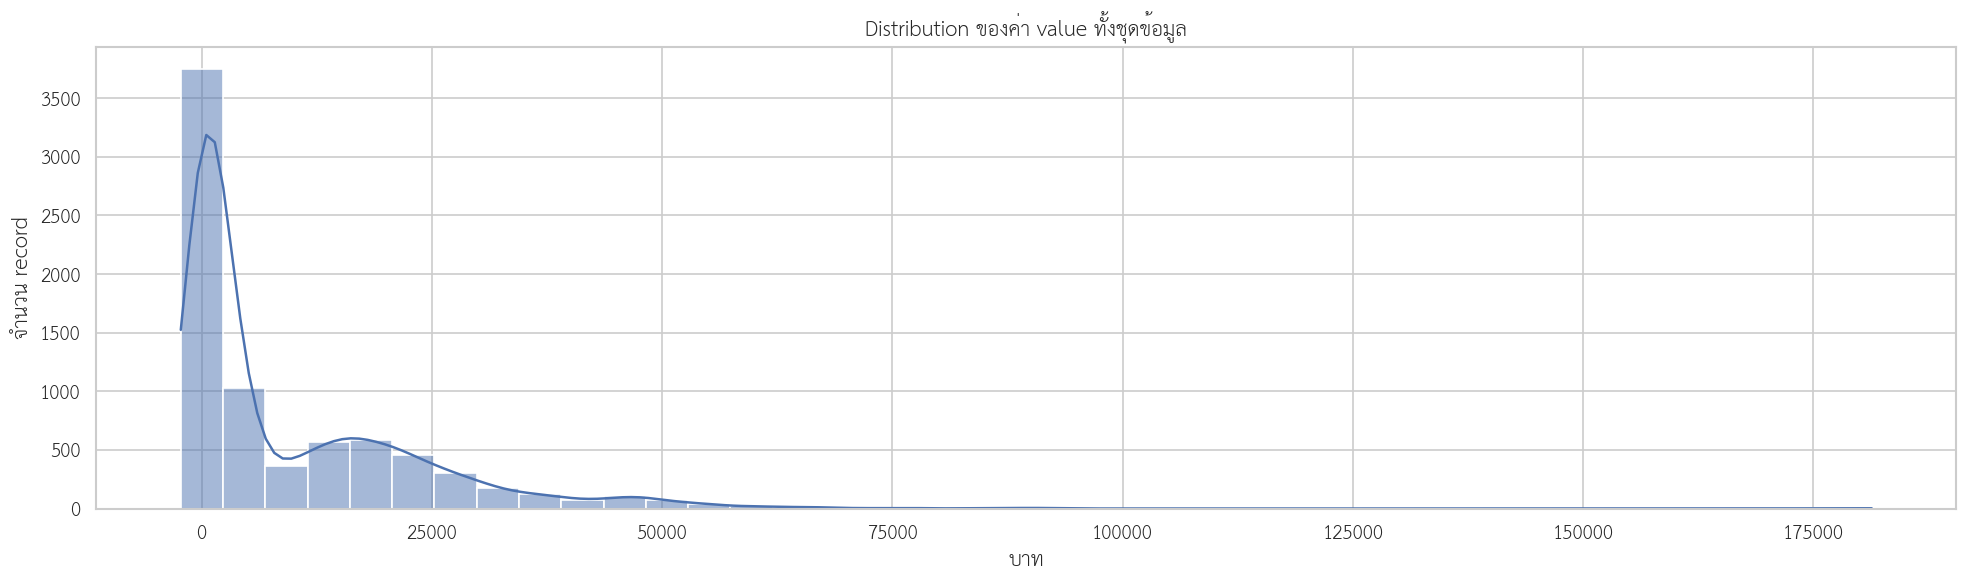

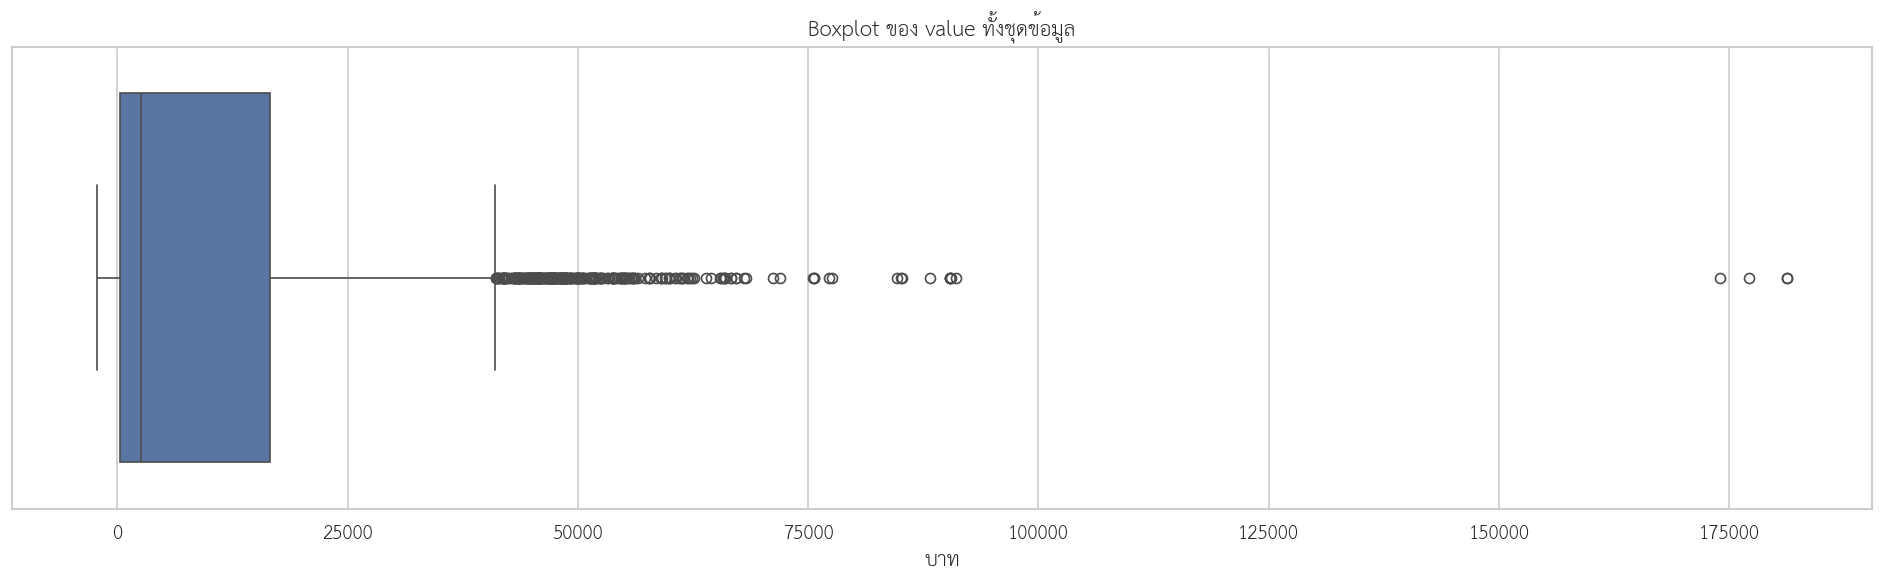

In [10]:
plt.figure(figsize=(20,5))
sns.histplot(df["value"], bins=40, kde=True)
plt.title("Distribution ของค่า value ทั้งชุดข้อมูล")
plt.xlabel("บาท")
plt.ylabel("จำนวน record")
plt.show()

plt.figure(figsize=(20,5))
sns.boxplot(x=df["value"])
plt.title("Boxplot ของ value ทั้งชุดข้อมูล")
plt.xlabel("บาท")
plt.show()

In [11]:
print("Median:", df["value"].median())
print("Mean:", df["value"].mean())
print("Min:", df["value"].min())
print("Max:", df["value"].max())

Median: 2588.5
Mean: 9697.004805194805
Min: -2250.0
Max: 181322.0


**การกระจายเบื้องต้นของข้อมูล**
  ซึ่งจะเห็นได้ว่าเป็นกราฟเบ้ขวาเป็นอย่างมากและ ยังมี outlier จำนวนมาก ซึ่งทำให้เห็นได้ว่ารายได้ค่อนข้างเกาะกลุ่มอยู่ทางฝั่งน้อยจนถึงไม่มีเลย

In [12]:
# ข้อ 1 และ ข้อ 2 ใช้ "รายได้ทั้งสิ้นต่อเดือน"
df_total = df[df["source_income3"] == "รายได้ทั้งสิ้นต่อเดือน"].copy()

# ข้อ 3 ใช้โครงสร้างรายได้ย่อย
income_components = [
    "ค่าจ้างและเงินเดือน",
    "กำไรสุทธิจากการทำธุรกิจ",
    "กำไรสุทธิจากการทำการเกษตร",
    "เงินที่ได้รับเป็นการช่วยเหลือ",
    "รายได้จากทรัพย์สิน",
    "รายได้ไม่ประจำ (ที่เป็นตัวเงิน)",
    "รายได้ที่ไม่เป็นตัวเงิน"
]
df_structure = df[df["source_income3"].isin(income_components)].copy()

print(df_total.shape, df_structure.shape)

(770, 12) (5390, 12)


# Q1

**1.ใครได้รับค่าตอบแทนแค่ไหน**

In [13]:
# ดึงข้อมูลที่ต้องการออกมา
q1_avg = (
    df_total
    .groupby(["soc_eco_class1", "soc_eco_class2"], as_index=False)["value"]
    .mean()
    .rename(columns={"value": "avg_income"})
    .sort_values("avg_income", ascending=False)
)

display(q1_avg)

,soc_eco_class1,soc_eco_class2,avg_income
7,ลูกจ้าง,ผู้จัดการนักวิชาการและผู้ปฏิบัติงานวิชาชีพ,48292.909091
3,ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร,ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร,33298.610390
2,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,27264.103896
9,ลูกจ้าง,เสมียนพนักงานขายและให้บริการ,25684.363636
1,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เช่าที่...,24048.220779
8,ลูกจ้าง,ผู้ปฏิบัติงานในกระบวนการผลิตก่อสร้างและเหมืองแร่,21971.142857
0,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ประมงป่าไม้ล่าสัตว์หาของป่าบริการทางการเกษตร,19668.519481
4,ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ,ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ,19514.909091
5,ลูกจ้าง,คนงานด้านการขนส่งและงานพื้นฐาน,18547.337662
6,ลูกจ้าง,คนงานเกษตรป่าไม้และประมง,14982.688312


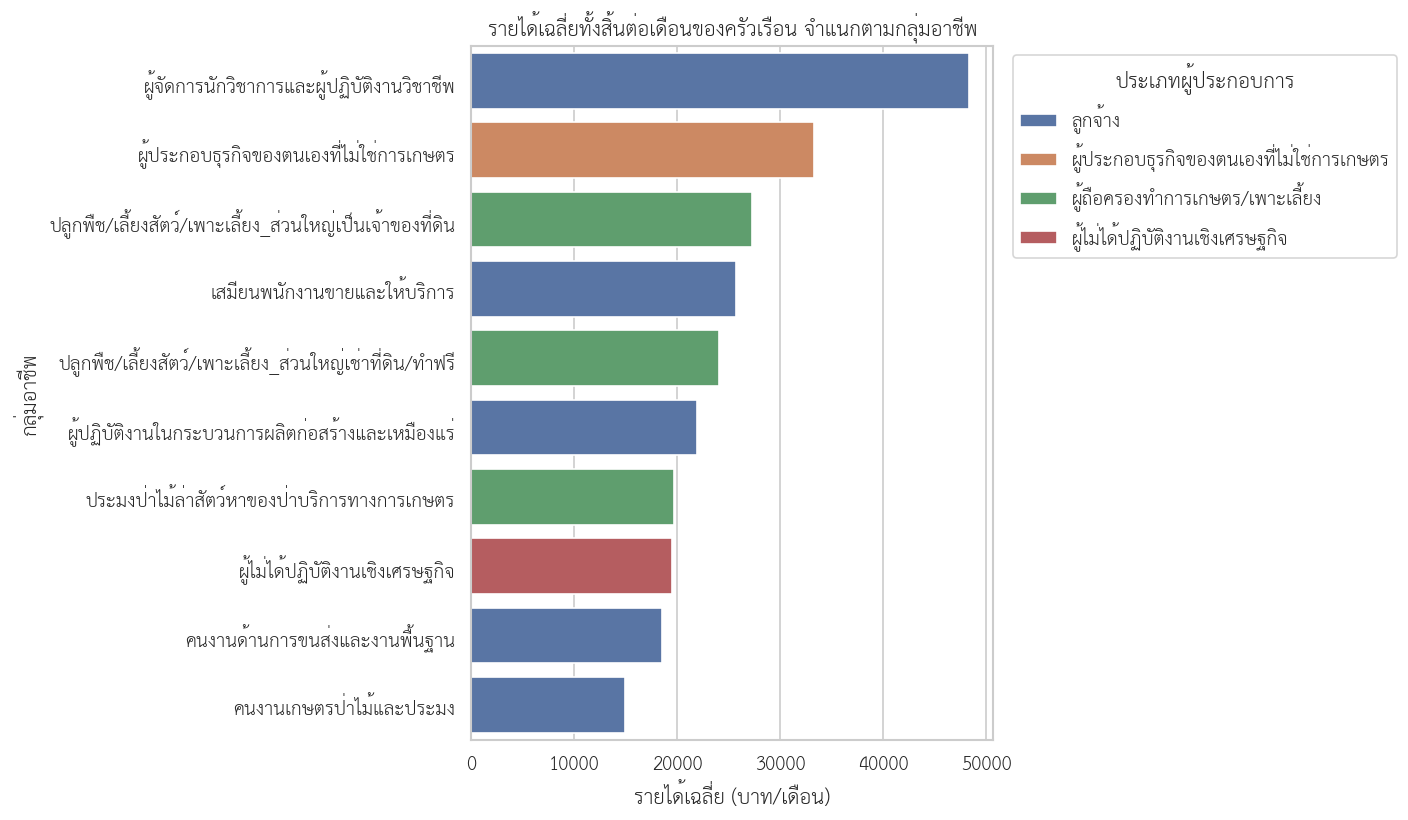

In [14]:
plt.figure(figsize=(12,7))
sns.barplot(
    data=q1_avg,
    y="soc_eco_class2",
    x="avg_income",
    hue="soc_eco_class1",
    dodge=False
)
plt.title("รายได้เฉลี่ยทั้งสิ้นต่อเดือนของครัวเรือน จำแนกตามกลุ่มอาชีพ")
plt.xlabel("รายได้เฉลี่ย (บาท/เดือน)")
plt.ylabel("กลุ่มอาชีพ")
plt.legend(title="ประเภทผู้ประกอบการ", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [15]:
top_group = q1_avg.iloc[0]
bottom_group = q1_avg.iloc[-1]

print("กลุ่มอาชีพรายได้เฉลี่ยสูงสุด")
print(top_group[["soc_eco_class1", "soc_eco_class2", "avg_income"]])

print("\nกลุ่มอาชีพรายได้เฉลี่ยต่ำสุด")
print(bottom_group[["soc_eco_class1", "soc_eco_class2", "avg_income"]])

กลุ่มอาชีพรายได้เฉลี่ยสูงสุด
soc_eco_class1                                       ลูกจ้าง
soc_eco_class2    ผู้จัดการนักวิชาการและผู้ปฏิบัติงานวิชาชีพ
avg_income                                      48292.909091
Name: 7, dtype: object

กลุ่มอาชีพรายได้เฉลี่ยต่ำสุด
soc_eco_class1                     ลูกจ้าง
soc_eco_class2    คนงานเกษตรป่าไม้และประมง
avg_income                    14982.688312
Name: 6, dtype: object


# Q1 answer

**ข้อที่ 1 ใครได้ค่าตอบแทนแค่ไหน
จากกราฟเห็นได้ว่า

---
สูงสุดคือ ผู้จัดการนักวิชาการและผู้ปฏิบัติงานวิชาชีพ เฉลี่ยประมาณ 48,293 บาท/เดือน
ต่ำสุดคือ คนงานเกษตรป่าไม้และประมง เฉลี่ยประมาณ 14,983 บาท/เดือน**


---

ซึ่งเห็นได้ว่าทั้งคู่ที่เป็น max และ min นั้นเป็นลูกจ้างด้วยกันทั้งคู่ซึ่งสามารถแสดงถึง *ช่องว่าง* ได้อย่างชัดเจน
ก็จะทำให้เห็นได้ว่าลูกจ้างนั้นมีหลากหลายระดับตาม *ทักษะ* ของลูกจ้าง

---
การเพิ่มรายได้โดยรวมจากทั้งประเทศอาจสามารถดูได้ที่กลุ่มลูกจ้างซึ่งเป็นรายได้ส่วนใหญ่ของประชากรไทย โดยอาจมีนโยบายสำหรับ กลุ่มตามความสามารถของทักษะของลูกจ้าง



# Q2

**2.ความเหลื่อมล้ำอยู่ที่ไหน?**

In [16]:
# ดึงข้อมูลที่ต้องการออกมา

q2_province = (
    df_total.groupby("province")
    .agg(
        avg_income=("value", "mean"),
        max_income=("value", "max"),
        min_income=("value", "min"),
        std_income=("value", "std")
    )
)

q2_province["gap"] = q2_province["max_income"] - q2_province["min_income"]
q2_province["cv"] = q2_province["std_income"] / q2_province["avg_income"]
q2_province = q2_province.sort_values("cv", ascending=False)

display(q2_province.head(15))

,avg_income,max_income,min_income,std_income,gap,cv
province,,,,,,
นราธิวาส,13965.0,46864.0,0.0,13511.420815,46864.0,0.967520
จันทบุรี,50893.0,181322.0,18092.0,48728.524293,163230.0,0.957470
ยโสธร,23814.3,77569.0,0.0,20721.608314,77569.0,0.870133
หนองบัวลำภู,28814.9,91028.0,13049.0,22994.148103,77979.0,0.797995
ศรีสะเกษ,28973.3,90406.0,13578.0,23100.225569,76828.0,0.797294
ชลบุรี,24564.5,46980.0,0.0,18673.383317,46980.0,0.760178
นนทบุรี,22788.8,53767.0,0.0,16924.001916,53767.0,0.742646
ยะลา,21515.8,51466.0,0.0,15785.819655,51466.0,0.733685
กรุงเทพมหานคร,26557.0,62571.0,0.0,19195.136884,62571.0,0.722790


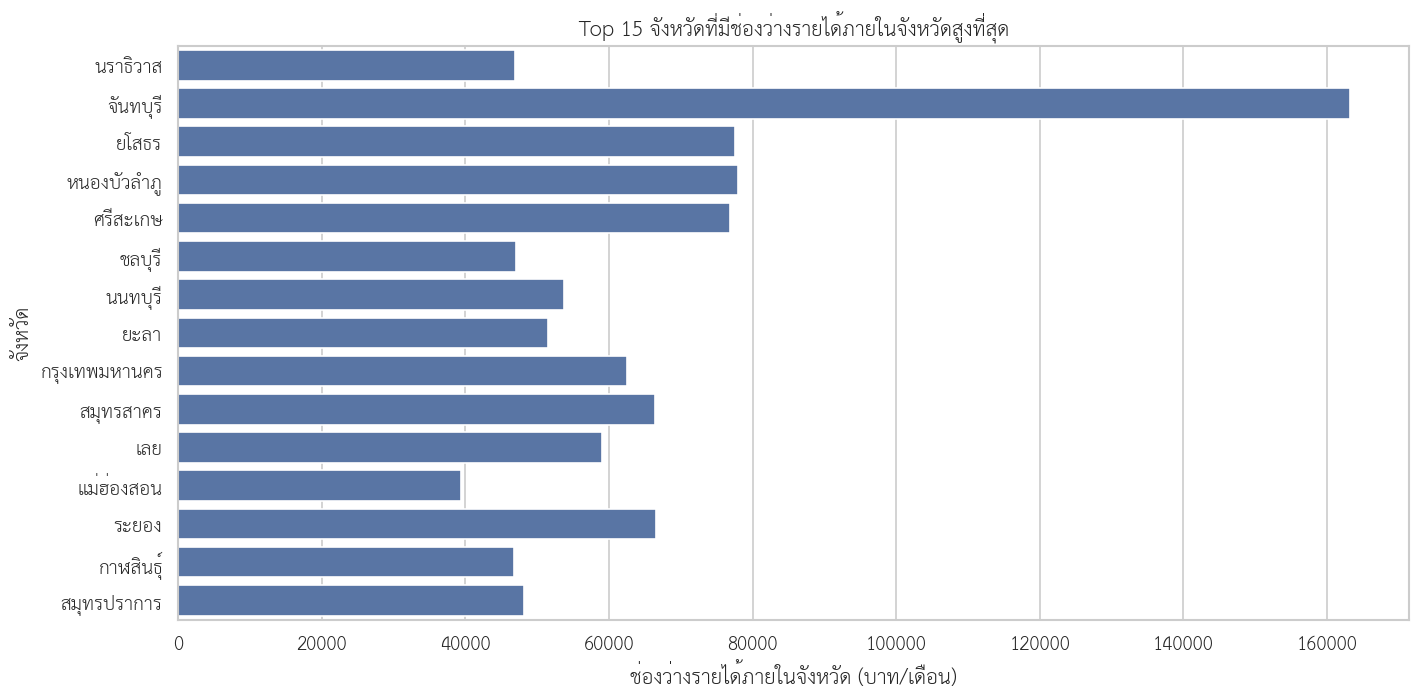

In [17]:
top15_gap = q2_province.head(15).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=top15_gap, x="gap", y="province")
plt.title("Top 15 จังหวัดที่มีช่องว่างรายได้ภายในจังหวัดสูงที่สุด")
plt.xlabel("ช่องว่างรายได้ภายในจังหวัด (บาท/เดือน)")
plt.ylabel("จังหวัด")
plt.tight_layout()
plt.show()

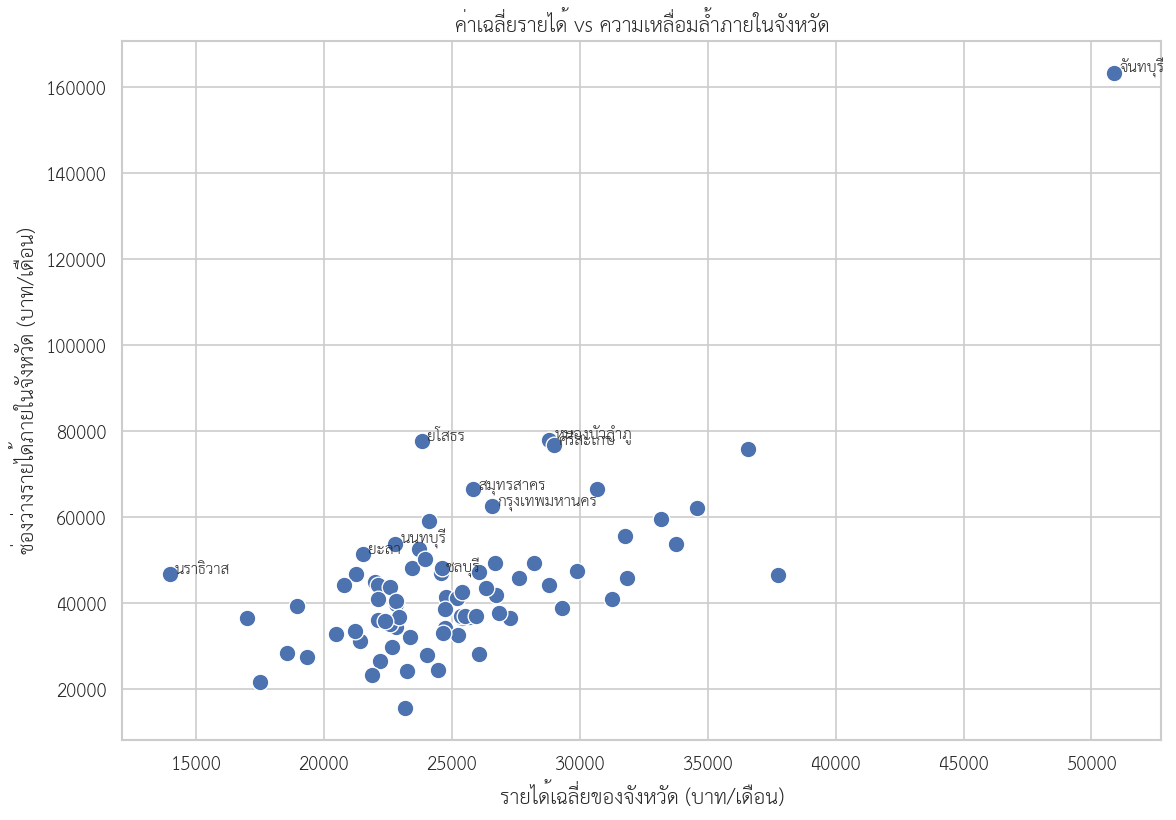

In [18]:
plot_df = q2_province.reset_index()

plt.figure(figsize=(10,7))
sns.scatterplot(data=plot_df, x="avg_income", y="gap", s=100)

# annotate top 10 gap
for _, row in plot_df.head(10).iterrows():
    plt.text(row["avg_income"] + 200, row["gap"] + 200, row["province"], fontsize=9)

plt.title("ค่าเฉลี่ยรายได้ vs ความเหลื่อมล้ำภายในจังหวัด")
plt.xlabel("รายได้เฉลี่ยของจังหวัด (บาท/เดือน)")
plt.ylabel("ช่องว่างรายได้ภายในจังหวัด (บาท/เดือน)")
plt.tight_layout()
plt.show()

ข้อมูลแปลกๆ ????

In [19]:
most_unequal_province = q2_province.index[0]
print("จังหวัดที่ gap สูงสุด:", most_unequal_province)

detail = (
    df_total[df_total["province"] == most_unequal_province]
    [["soc_eco_class1", "soc_eco_class2", "value"]]
    .sort_values("value", ascending=False)
)

display(detail)

จังหวัดที่ gap สูงสุด: นราธิวาส


,soc_eco_class1,soc_eco_class2,value
7640,ลูกจ้าง,ผู้จัดการนักวิชาการและผู้ปฏิบัติงานวิชาชีพ,46864.0
7637,ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร,ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร,21175.0
7670,ลูกจ้าง,เสมียนพนักงานขายและให้บริการ,17376.0
7680,ลูกจ้าง,ผู้ปฏิบัติงานในกระบวนการผลิตก่อสร้างและเหมืองแร่,15359.0
7660,ลูกจ้าง,คนงานด้านการขนส่งและงานพื้นฐาน,14300.0
7690,ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ,ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ,9882.0
7650,ลูกจ้าง,คนงานเกษตรป่าไม้และประมง,7938.0
7600,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,6756.0
7610,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เช่าที่...,0.0
7624,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ประมงป่าไม้ล่าสัตว์หาของป่าบริการทางการเกษตร,0.0


# Q2 problem

**ข้อที่ 2 ความเหลื่อมล้ำอยู่ที่ไหน?**
จากกราฟ Top 15 เห็นได้ว่า

---
จากการวิเคราะห์โดยใช้ทั้ง max - min ก็จะสามารถเห็นได้ว่า *จังหวัดจันทบุรี* เป็นจังหวัดที่มีความเหลื่อมล้ำมากที่สุด ซึ่งก็ควรจะเน้นลดความเหลื่อมล้ำมากกว่าพยายามเพิ่มรายได้

---
แต่!!!!!!!!!!!!!!!!!!!!!!!
จากข้อมูลข้างบนที่แสดงรายได้ครัวเรือนของจันทบุรีจะเห็นได้ว่า Top1 กับ Top2 มีค่าต่างกันเป็นอย่างมาก ซึ่งผมก็จะวิเคราะห์เสริมอีกแบบคือลองตัดตัว outlier จากทุกจังหวัดออกไปและเทียบกันดู ในบรรทัดต่อๆไป

---



In [20]:
def province_robust_stats(g):
    x = g["value"].dropna()
    return pd.Series({
        "mean": x.mean(),
        "median": x.median(),
        "p90": x.quantile(0.9),
        "p10": x.quantile(0.1),
        "p90_p10_gap": x.quantile(0.9) - x.quantile(0.1),
        "iqr": x.quantile(0.75) - x.quantile(0.25),
        "max_min_gap": x.max() - x.min()
    })

q2_robust = df_total.groupby("province").apply(province_robust_stats).reset_index()
display(q2_robust.sort_values("p90_p10_gap", ascending=False).head(15))

/tmp/ipykernel_194/3628889824.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  q2_robust = df_total.groupby("province").apply(province_robust_stats).reset_index()


,province,mean,median,p90,p10,p90_p10_gap,iqr,max_min_gap
6,จันทบุรี,50893.0,36675.0,77534.0,20658.8,56875.2,31325.50,163230.0
1,กรุงเทพมหานคร,26557.0,27299.0,50178.0,0.0,50178.0,10688.00,62571.0
8,ชลบุรี,24564.5,28854.5,45176.4,0.0,45176.4,33756.50,46980.0
21,นนทบุรี,22788.8,23124.0,42094.9,0.0,42094.9,16882.75,53767.0
19,นครศรีธรรมราช,31827.9,25423.5,57775.2,16130.9,41644.3,18647.75,45922.0
42,ระยอง,30685.1,26467.5,53306.4,12329.1,40977.3,24975.25,66594.0
43,ราชบุรี,36594.3,29180.5,59023.1,18223.7,40799.4,21200.00,75795.0
39,ยะลา,21515.8,19338.5,46279.3,7780.5,38498.8,8403.25,51466.0
71,เชียงใหม่,26725.1,23020.5,51007.5,12580.2,38427.3,10643.25,41823.0
18,นครราชสีมา,28211.6,25373.5,49440.7,11844.1,37596.6,9233.25,49302.0


In [21]:
# ใช้ข้อมูลสำหรับข้อ 2
df_q2 = df[df["source_income3"] == "รายได้ทั้งสิ้นต่อเดือน"].copy()

def add_iqr_outlier_flag(group, value_col="value"):
    q1 = group[value_col].quantile(0.25)
    q3 = group[value_col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    group = group.copy()
    group["q1"] = q1
    group["q3"] = q3
    group["iqr"] = iqr
    group["lower_bound"] = lower
    group["upper_bound"] = upper
    group["is_outlier_iqr"] = (group[value_col] < lower) | (group[value_col] > upper)
    return group

df_q2_flagged = (
    df_q2.groupby("province", group_keys=False)
         .apply(add_iqr_outlier_flag)
         .reset_index(drop=True)
)

display(df_q2_flagged.head())

/tmp/ipykernel_194/2332151412.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_iqr_outlier_flag)


,year,province,source_income1,source_income2,source_income3,soc_eco_class1,soc_eco_class2,value,unit,attribute,source,zero_flag,q1,q3,iqr,lower_bound,upper_bound,is_outlier_iqr
0,2566,กรุงเทพมหานคร,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้...,29549.0,บาท,NaN,สำนักงานสถิติแห่งชาติ,False,18884.25,29572.25,10688.0,2852.25,45604.25,False
1,2566,กรุงเทพมหานคร,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เช่าที่...,0.0,บาท,ศูนย์ยกกำลังดับเบิลยู หมายถึง ข้อมูลจากการสำรว...,สำนักงานสถิติแห่งชาติ,True,18884.25,29572.25,10688.0,2852.25,45604.25,True
2,2566,กรุงเทพมหานคร,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,ผู้ถือครองทำการเกษตร/เพาะเลี้ยง,ประมงป่าไม้ล่าสัตว์หาของป่าบริการทางการเกษตร,0.0,บาท,ศูนย์ยกกำลังดับเบิลยู หมายถึง ข้อมูลจากการสำรว...,สำนักงานสถิติแห่งชาติ,True,18884.25,29572.25,10688.0,2852.25,45604.25,True
3,2566,กรุงเทพมหานคร,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร,ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร,48801.0,บาท,NaN,สำนักงานสถิติแห่งชาติ,False,18884.25,29572.25,10688.0,2852.25,45604.25,True
4,2566,กรุงเทพมหานคร,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,รายได้ทั้งสิ้นต่อเดือน,ลูกจ้าง,ผู้จัดการนักวิชาการและผู้ปฏิบัติงานวิชาชีพ,62571.0,บาท,NaN,สำนักงานสถิติแห่งชาติ,False,18884.25,29572.25,10688.0,2852.25,45604.25,True


In [22]:
# function ในการวัดข้อมูลรายได้
def province_metrics(group, value_col="value"):
    x = group[value_col].dropna()

    if len(x) == 0:
        return pd.Series({
            "n": 0,
            "mean": np.nan,
            "median": np.nan,
            "std": np.nan,
            "cv": np.nan,
            "min": np.nan,
            "max": np.nan,
            "max_min_gap": np.nan,
            "p10": np.nan,
            "p90": np.nan,
            "p90_p10_gap": np.nan,
            "q1": np.nan,
            "q3": np.nan,
            "iqr": np.nan
        })

    mean_val = x.mean()
    std_val = x.std()

    return pd.Series({
        "n": len(x),
        "mean": mean_val,
        "median": x.median(),
        "std": std_val,
        "cv": std_val / mean_val if mean_val != 0 else np.nan,
        "min": x.min(),
        "max": x.max(),
        "max_min_gap": x.max() - x.min(),
        "p10": x.quantile(0.10),
        "p90": x.quantile(0.90),
        "p90_p10_gap": x.quantile(0.90) - x.quantile(0.10),
        "q1": x.quantile(0.25),
        "q3": x.quantile(0.75),
        "iqr": x.quantile(0.75) - x.quantile(0.25)
    })

In [23]:
# ก่อนตัด outlier
province_before = (
    df_q2_flagged.groupby("province")
    .apply(province_metrics)
    .reset_index()
)

# หลังตัด outlier
df_q2_no_outlier = df_q2_flagged[~df_q2_flagged["is_outlier_iqr"]].copy()

province_after = (
    df_q2_no_outlier.groupby("province")
    .apply(province_metrics)
    .reset_index()
)

display(province_before.head())
display(province_after.head())

/tmp/ipykernel_194/2950368073.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(province_metrics)
/tmp/ipykernel_194/2950368073.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(province_metrics)


,province,n,mean,median,std,cv,min,max,max_min_gap,p10,p90,p90_p10_gap,q1,q3,iqr
0,กระบี่,10.0,23704.3,20909.0,13749.548906,0.580045,0.0,52555.0,52555.0,13472.1,34035.7,20563.6,17191.50,30356.25,13164.75
1,กรุงเทพมหานคร,10.0,26557.0,27299.0,19195.136884,0.722790,0.0,62571.0,62571.0,0.0,50178.0,50178.0,18884.25,29572.25,10688.00
2,กาญจนบุรี,10.0,26072.2,23687.0,8179.705018,0.313733,15236.0,43315.0,28079.0,19920.5,33830.8,13910.3,20727.75,30090.50,9362.75
3,กาฬสินธุ์,10.0,21260.4,17385.5,13608.433996,0.640084,0.0,46726.0,46726.0,11308.5,36055.6,24747.1,13559.75,30923.25,17363.50
4,กำแพงเพชร,10.0,23160.7,25346.0,5738.124549,0.247753,15000.0,30670.0,15670.0,15618.3,28384.9,12766.6,17386.25,27225.00,9838.75


,province,n,mean,median,std,cv,min,max,max_min_gap,p10,p90,p90_p10_gap,q1,q3,iqr
0,กระบี่,9.0,20498.666667,20281.0,9852.684913,0.480650,0.0,31978.0,31978.0,11975.2,31142.8,19167.6,16300.00,28623.00,12323.00
1,กรุงเทพมหานคร,6.0,25699.666667,27299.0,4675.835056,0.181941,17533.0,29580.0,12047.0,20235.5,29564.5,9329.0,24014.75,29000.00,4985.25
2,กาญจนบุรี,10.0,26072.200000,23687.0,8179.705018,0.313733,15236.0,43315.0,28079.0,19920.5,33830.8,13910.3,20727.75,30090.50,9362.75
3,กาฬสินธุ์,10.0,21260.400000,17385.5,13608.433996,0.640084,0.0,46726.0,46726.0,11308.5,36055.6,24747.1,13559.75,30923.25,17363.50
4,กำแพงเพชร,10.0,23160.700000,25346.0,5738.124549,0.247753,15000.0,30670.0,15670.0,15618.3,28384.9,12766.6,17386.25,27225.00,9838.75


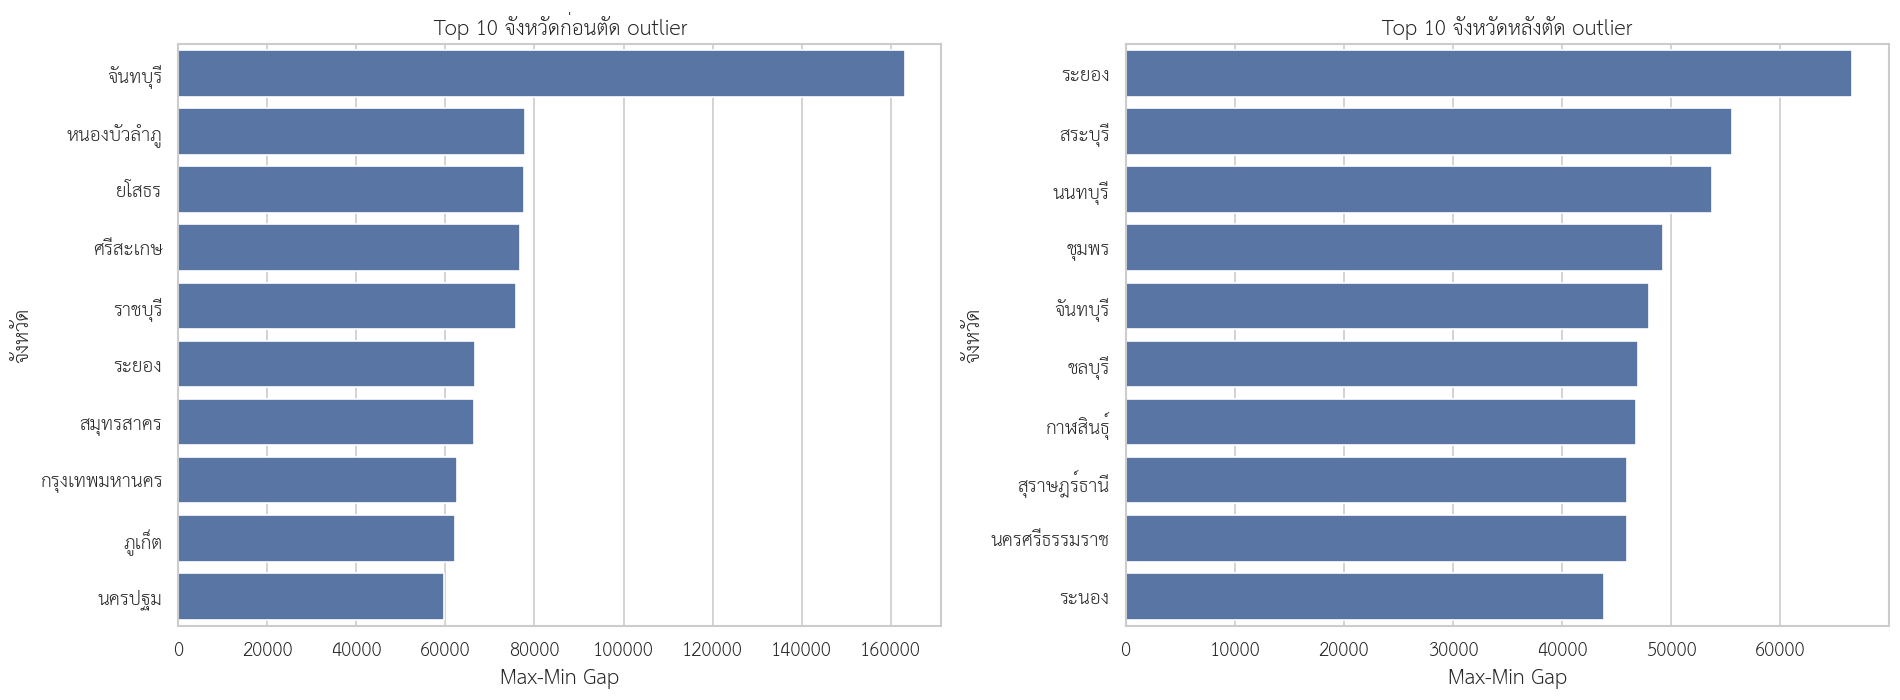

In [24]:
top10_before = province_before.sort_values("max_min_gap", ascending=False).head(10)
top10_after = province_after.sort_values("max_min_gap", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top10_before, x="max_min_gap", y="province", ax=axes[0])
axes[0].set_title("Top 10 จังหวัดก่อนตัด outlier")
axes[0].set_xlabel("Max-Min Gap")
axes[0].set_ylabel("จังหวัด")

sns.barplot(data=top10_after, x="max_min_gap", y="province", ax=axes[1])
axes[1].set_title("Top 10 จังหวัดหลังตัด outlier")
axes[1].set_xlabel("Max-Min Gap")
axes[1].set_ylabel("จังหวัด")

plt.tight_layout()
plt.show()

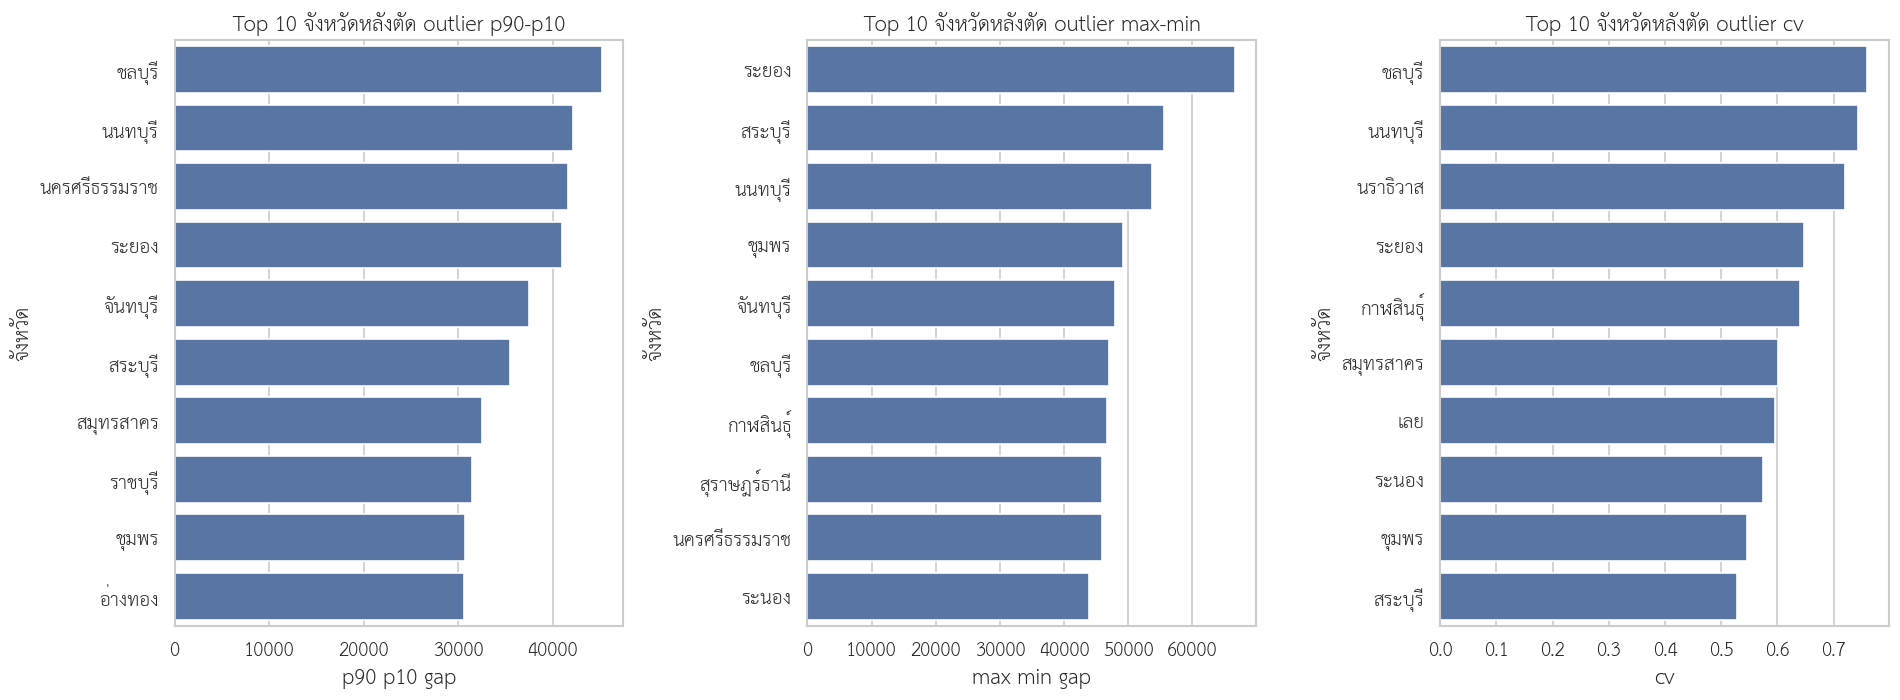

In [38]:
# หลังตัด outlier
top10_after_pct = province_after.sort_values("p90_p10_gap", ascending=False).head(10)
top10_after_maxmin = province_after.sort_values("max_min_gap", ascending=False).head(10)
top10_after_cv = province_after.sort_values("cv", ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

sns.barplot(data=top10_after_pct, x="p90_p10_gap", y="province", ax=axes[0])
axes[0].set_title("Top 10 จังหวัดหลังตัด outlier p90-p10")
axes[0].set_xlabel("p90 p10 gap")
axes[0].set_ylabel("จังหวัด")

sns.barplot(data=top10_after_maxmin, x="max_min_gap", y="province", ax=axes[1])
axes[1].set_title("Top 10 จังหวัดหลังตัด outlier max-min")
axes[1].set_xlabel("max min gap")
axes[1].set_ylabel("จังหวัด")

sns.barplot(data=top10_after_cv, x="cv", y="province", ax=axes[2])
axes[2].set_title("Top 10 จังหวัดหลังตัด outlier cv")
axes[2].set_xlabel("cv")
axes[2].set_ylabel("จังหวัด")

plt.tight_layout()
plt.show()

# Q2 answer

**(ต่อ) ข้อที่ 2 ความเหลื่อมล้ำอยู่ที่ไหน?**
จากกราฟ Top 10 (ใหม่) เห็นได้ว่า

---
หลังจากตัด outlier ทั้งหมดอันดับมีการเปลี่ยนอย่างชัดเจนเมื่อมองภาพรวม (p90-p10) เห็นได้ว่าข้อมูลเกาะกลุ่มกันมากขึ้นและ *ชลบุรี* ขึ้นมาเป็นที่ 1 ที่โดยรวมมีความเหลื่อมล้ำสูง แต่มองเชิง max-min *ระยอง* จะมาเป็นอันดับ 1

---

จากข้อมูลทั้งหมดผมจึงเห็นว่าควรใช่ค่า CV มาใช้วัดเนื่องจากค่า CV จะเป็นการ normalize ในตัวทำให้สามารถเห็นความเหลื่อมล้ำในภาพรวมได้ และสามารถเทียบกับจังหวัดอื่นๆได้ในมาตรฐานเดียวกัน

---

ซึ่งผลลัพทธ์ที่ออกมาคือ ชลบุุรี มาเป็นที่ 1 ทั้งใน cv และเกณ์ percentile ซึ่งได้ชัดว่ามีความเลื่อมล้ำชัดเจน จึงควรจะเน้นการลดความเหลื่อมล้ำ ควรจะให้ครัวเรือนที่มีรายได้น้อยมีรายได้มากขึ้่้น ไม่ว่าจะจ้างงาน หรือสนับสนุนธุรกิจอุตสาหกรรมต่างๆ

# Q3

**3. รายได้มาจากไหน และใครพึ่งพาอะไร**

In [26]:
# ดึงข้อมูลที่ต้องการออกมา
q3_pivot = (
    df_structure
    .pivot_table(
        index=["soc_eco_class1", "soc_eco_class2"],
        columns="source_income3",
        values="value",
        aggfunc="mean"
    )
    .fillna(0)
)

display(q3_pivot)

source_income3                                                                               กำไรสุทธิจากการทำการเกษตร  กำไรสุทธิจากการทำธุรกิจ  ค่าจ้างและเงินเดือน  รายได้จากทรัพย์สิน  \
soc_eco_class1                           soc_eco_class2                                                                                                                                    
ผู้ถือครองทำการเกษตร/เพาะเลี้ยง          ประมงป่าไม้ล่าสัตว์หาของป่าบริการทางการเกษตร                     12305.298701               739.129870          1777.818182           23.597403   
                                         ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เช่าที่ด...               16533.441558               769.532468          1432.402597           18.597403   
                                         ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้า...               18551.064935               596.311688          1698.532468           96.935065   
ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร                           787.870130             24349.298701          1996.519481          182.285714   
ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ          ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ                                    603.480519               556.051948          1102.389610          549.181818   
ลูกจ้าง                                  คนงานด้านการขนส่งและงานพื้นฐาน                                     418.064935               499.051948         12975.220779           21.519481   
                                         คนงานเกษตรป่าไม้และประมง                                           404.051948               192.337662         10029.805195           14.259740   
                                         ผู้จัดการนักวิชาการและผู้ปฏิบัติงานวิชาชีพ                        1093.246753              1551.220779         37553.610390          564.272727   
                                         ผู้ปฏิบัติงานในกระบวนการผลิตก่อสร้างและเหมืองแร่                   524.259740               557.168831         16083.298701           36.480519   
                                         เสมียนพนักงานขายและให้บริการ                                       690.792208              1026.454545         18450.285714           87.441558   

source_income3                                                                               รายได้ที่ไม่เป็นตัวเงิน  รายได้ไม่ประจำ (ที่เป็นตัวเงิน)  เงินที่ได้รับเป็นการช่วยเหลือ  
soc_eco_class1                           soc_eco_class2                                                                                                                               
ผู้ถือครองทำการเกษตร/เพาะเลี้ยง          ประมงป่าไม้ล่าสัตว์หาของป่าบริการทางการเกษตร                    3605.974026                        82.753247                    1133.870130  
                                         ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เช่าที่ด...              3381.194805                       173.844156                    1739.298701  
                                         ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้า...              4204.220779                       178.415584                    1938.753247  
ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร                        4158.233766                       301.038961                    1523.571429  
ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ          ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ                                 4464.194805                       831.441558                   11408.142857  
ลูกจ้าง                                  คนงานด้านการขนส่งและงานพื้นฐาน                                  3413.454545                       131.350649                    1088.571429  
                                         คนงานเกษตรป่าไม้และประมง                                        3261.454545                       115.246753                     965.519481  
                                         ผู้จัดการนักวิชาการและผู้ปฏิบัติงานวิชาชีพ             

In [27]:
# normalize
q3_share = q3_pivot.div(q3_pivot.sum(axis=1), axis=0)

display((q3_share * 100).round(2))

source_income3                                                                               กำไรสุทธิจากการทำการเกษตร  กำไรสุทธิจากการทำธุรกิจ  ค่าจ้างและเงินเดือน  รายได้จากทรัพย์สิน  \
soc_eco_class1                           soc_eco_class2                                                                                                                                    
ผู้ถือครองทำการเกษตร/เพาะเลี้ยง          ประมงป่าไม้ล่าสัตว์หาของป่าบริการทางการเกษตร                            62.56                     3.76                 9.04                0.12   
                                         ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เช่าที่ด...                      68.75                     3.20                 5.96                0.08   
                                         ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้า...                      68.04                     2.19                 6.23                0.36   
ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร                                 2.37                    73.12                 6.00                0.55   
ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ          ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ                                          3.09                     2.85                 5.65                2.81   
ลูกจ้าง                                  คนงานด้านการขนส่งและงานพื้นฐาน                                           2.25                     2.69                69.96                0.12   
                                         คนงานเกษตรป่าไม้และประมง                                                 2.70                     1.28                66.94                0.10   
                                         ผู้จัดการนักวิชาการและผู้ปฏิบัติงานวิชาชีพ                               2.26                     3.21                77.76                1.17   
                                         ผู้ปฏิบัติงานในกระบวนการผลิตก่อสร้างและเหมืองแร่                         2.39                     2.54                73.20                0.17   
                                         เสมียนพนักงานขายและให้บริการ                                             2.69                     4.00                71.83                0.34   

source_income3                                                                               รายได้ที่ไม่เป็นตัวเงิน  รายได้ไม่ประจำ (ที่เป็นตัวเงิน)  เงินที่ได้รับเป็นการช่วยเหลือ  
soc_eco_class1                           soc_eco_class2                                                                                                                               
ผู้ถือครองทำการเกษตร/เพาะเลี้ยง          ประมงป่าไม้ล่าสัตว์หาของป่าบริการทางการเกษตร                          18.33                             0.42                           5.76  
                                         ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เช่าที่ด...                    14.06                             0.72                           7.23  
                                         ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้า...                    15.42                             0.65                           7.11  
ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร                              12.49                             0.90                           4.58  
ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ          ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ                                       22.88                             4.26                          58.46  
ลูกจ้าง                                  คนงานด้านการขนส่งและงานพื้นฐาน                                        18.40                             0.71                           5.87  
                                         คนงานเกษตรป่าไม้และประมง                                              21.77                             0.77                           6.44  
                                         ผู้จัดการนักวิชาการและผู้ปฏิบัติงานวิชาชีพ             

In [28]:
q3_summary = pd.DataFrame(index=q3_share.index)
q3_summary["dominant_source"] = q3_share.idxmax(axis=1)
q3_summary["dominant_share"] = q3_share.max(axis=1)
q3_summary["HHI"] = (q3_share ** 2).sum(axis=1)

q3_summary = q3_summary.sort_values("HHI", ascending=False)
display(q3_summary)

dominant_source  dominant_share       HHI
soc_eco_class1                           soc_eco_class2                                                                                             
ลูกจ้าง                                  ผู้จัดการนักวิชาการและผู้ปฏิบัติงานวิชาชีพ                    ค่าจ้างและเงินเดือน        0.777621  0.618662
                                         ผู้ปฏิบัติงานในกระบวนการผลิตก่อสร้างและเหมืองแร่              ค่าจ้างและเงินเดือน        0.732019  0.565397
ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร                  กำไรสุทธิจากการทำธุรกิจ        0.731236  0.556660
ลูกจ้าง                                  เสมียนพนักงานขายและให้บริการ                                  ค่าจ้างและเงินเดือน        0.718342  0.543494
                                         คนงานด้านการขนส่งและงานพื้นฐาน                                ค่าจ้างและเงินเดือน        0.699577  0.528008
ผู้ถือครองทำการเกษตร/เพาะเลี้ยง          ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เช่าที่ด...      กำไรสุทธิจากการทำการเกษตร        0.687509  0.502293
ลูกจ้าง                                  คนงานเกษตรป่าไม้และประมง                                      ค่าจ้างและเงินเดือน        0.669427  0.500623
ผู้ถือครองทำการเกษตร/เพาะเลี้ยง          ปลูกพืช/เลี้ยงสัตว์/เพาะเลี้ยง_ส่วนใหญ่เป็นเจ้า...      กำไรสุทธิจากการทำการเกษตร        0.680418  0.496218
                                         ประมงป่าไม้ล่าสัตว์หาของป่าบริการทางการเกษตร            กำไรสุทธิจากการทำการเกษตร        0.625637  0.437959
ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ          ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ                     เงินที่ได้รับเป็นการช่วยเหลือ        0.584587  0.401639

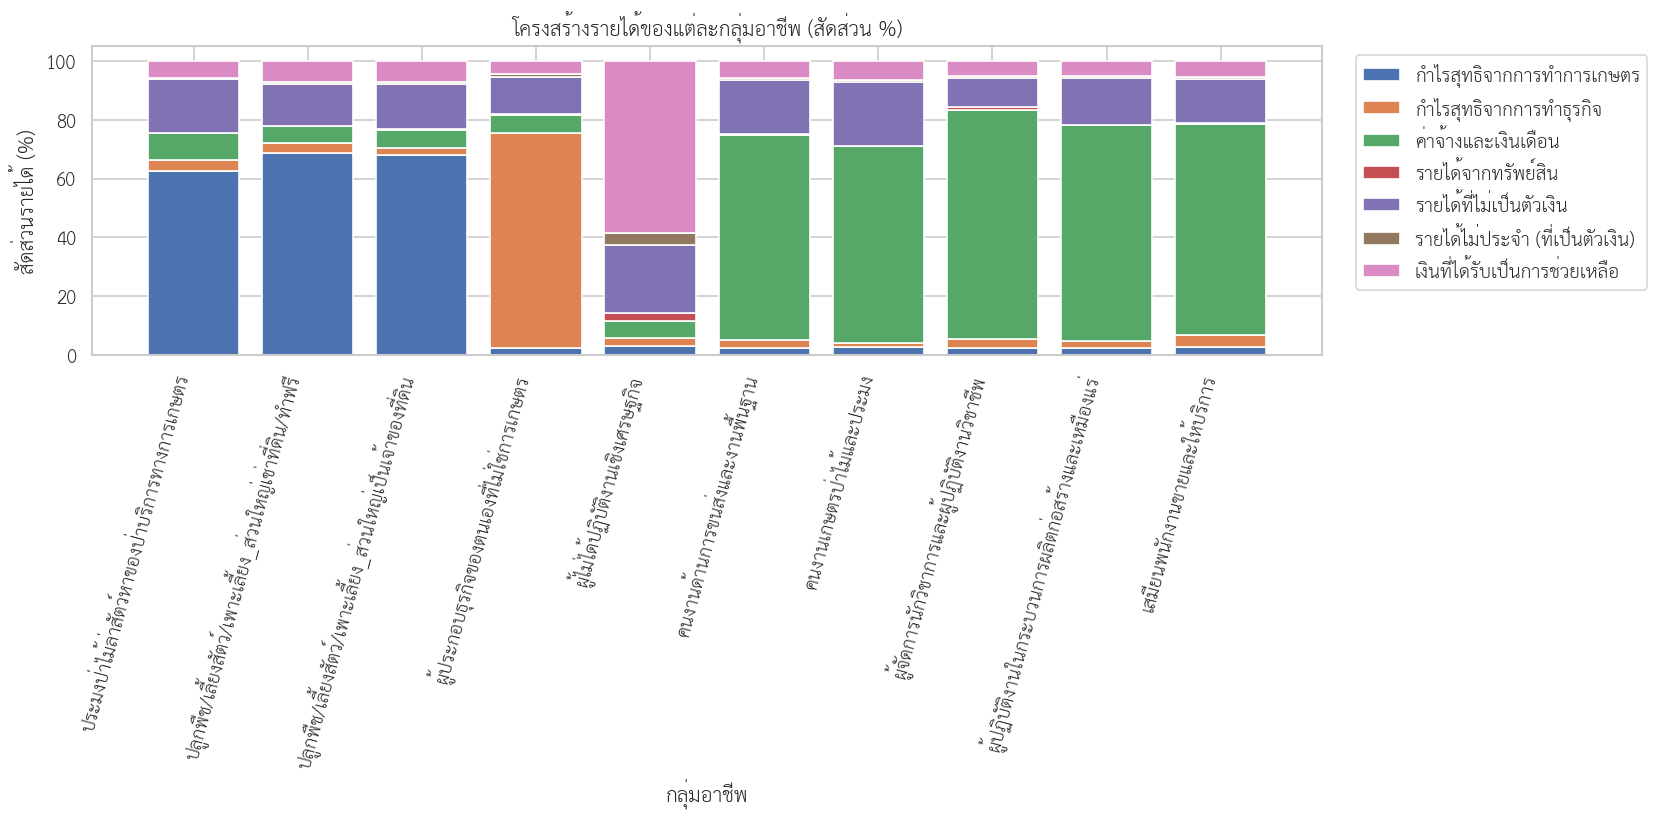

In [29]:
q3_plot = (q3_share * 100).reset_index()
q3_plot["group_name"] = q3_plot["soc_eco_class2"]

plot_cols = q3_share.columns.tolist()

# วาด stacked bar
fig, ax = plt.subplots(figsize=(14,7))

bottom = np.zeros(len(q3_plot))
for col in plot_cols:
    ax.bar(q3_plot["group_name"], q3_plot[col], bottom=bottom, label=col)
    bottom += q3_plot[col].values

ax.set_title("โครงสร้างรายได้ของแต่ละกลุ่มอาชีพ (สัดส่วน %)")
ax.set_ylabel("สัดส่วนรายได้ (%)")
ax.set_xlabel("กลุ่มอาชีพ")
plt.xticks(rotation=75, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

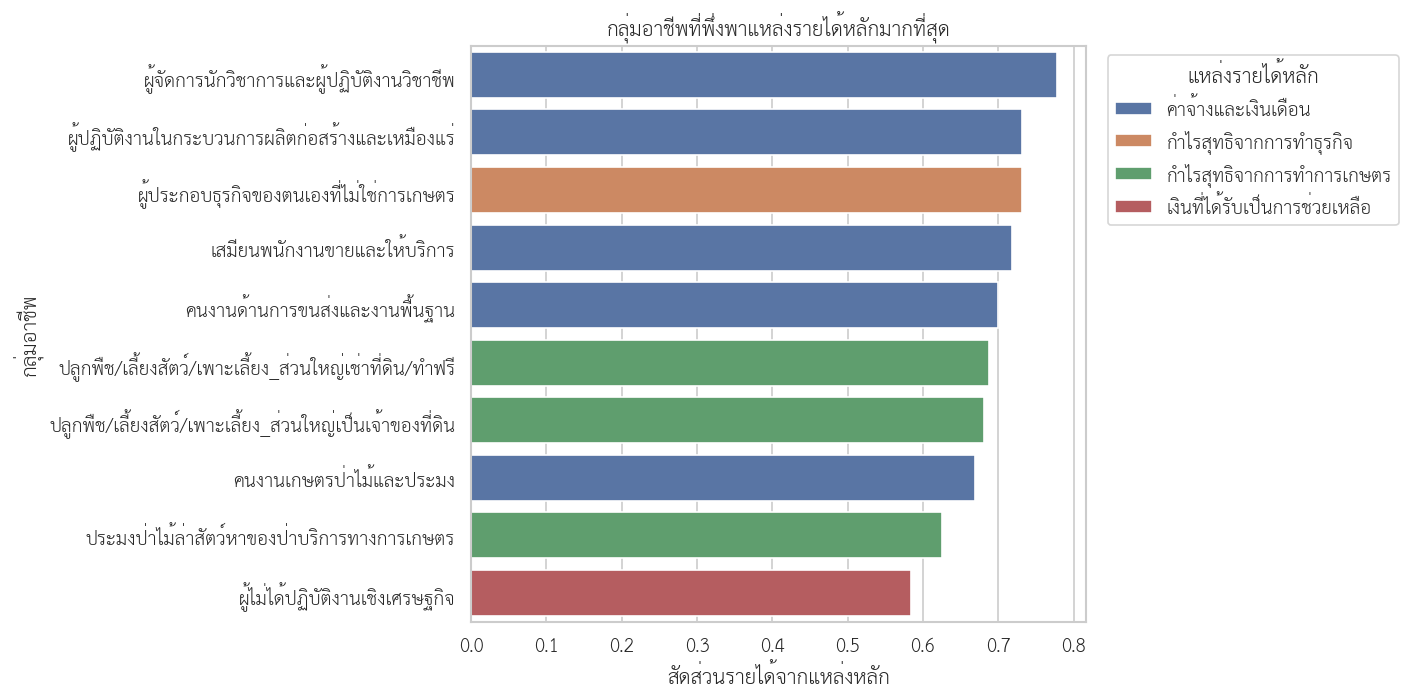

In [30]:
q3_concentrated = q3_summary.reset_index().sort_values("dominant_share", ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=q3_concentrated, x="dominant_share", y="soc_eco_class2", hue="dominant_source", dodge=False)
plt.title("กลุ่มอาชีพที่พึ่งพาแหล่งรายได้หลักมากที่สุด")
plt.xlabel("สัดส่วนรายได้จากแหล่งหลัก")
plt.ylabel("กลุ่มอาชีพ")
plt.legend(title="แหล่งรายได้หลัก", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Q3 answer

**ข้อที่ 3 รายได้มาจากไหน ใครพึ่งพาอะไร**
จากกราฟ เห็นได้ว่า

---
ลูกจ้าง: พึ่งพา "ค่าจ้างและเงินเดือน" เป็นหลัก - โครงสร้างรายได้เสถียร แต่มีความเสี่ยงจากการว่างงาน

เจ้าของกิจการ: พึ่งพา "กำไรสุทธิจากธุรกิจ" เป็นหลัก  รายได้ขึ้นอยู่กับประสิทธิภาพของธุรกิจ

เกษตรกร: พึ่งพา "กำไรจากการเกษตร" เป็นหลัก  - มีหลายแหล่งรายได้เสริม แต่ยังคงเสี่ยงต่อภัยธรรมชาติและราคาสินค้า

---

จากกราฟจะเห็นได้ว่ากลุ่มลูกจ้างพึ่งพารายได้หลัก (เงินเดือน) มากที่สุดดังนั้น การตกงานจะเป็นอุปสรรคใหญ่ที่สุดของคนเหล่านี้ นโยบายควรสนับสนุนการจ้างงานมากขึ้น ลงทุนในอุตสาหกรรมต่างๆเพื่อเกิดการจ้างงานและคงรายได้ของคนกลุ่มนี้ไว้

**600345 ไทโย**
Visualization website: https://income-visualize66.vercel.app/